# Weighted LSTM regime aware GARCH with soft switching

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

In [2]:
# load data
df = pd.read_csv('../data/df_with_2regimes.csv')
df["date"] = pd.to_datetime(df["date"])
# check for na
df.isna().sum()

# drop na (first 29 days of data)
df = df.dropna()

In [3]:
# split data into train, evaluation and out of sample test sets 70/15/15

train_size = int(len(df) * 0.7)
eval_size = int(len(df) * 0.15)
train_df = df.iloc[:train_size]

eval_df = df.iloc[train_size:train_size + eval_size]
test_df = df.iloc[train_size + eval_size:]
print(f"Train set: {len(train_df)} rows")
print(f"Evaluation set: {len(eval_df)} rows")
print(f"Test set: {len(test_df)} rows")


Train set: 2442 rows
Evaluation set: 523 rows
Test set: 524 rows


In [4]:
lstm_features = [
    "blockchain_diff_log_n_transactions",
    "blockchain_diff_log_transaction_fee_usd",
    "blockchain_diff_log_n_unique_addresses",
    "blockchain_diff_log_transaction_volume_usd",
    "hash-rate_chg", 
    "difficulty_chg", 
    "median-confirmation-time_chg", 
    "blockchain_log_mempool_count_chg"
    ]

garch_features = [] # to be added later 
    

X_train_lstm = train_df[lstm_features]
X_eval_lstm  = eval_df[lstm_features]
X_test_lstm  = test_df[lstm_features]

y_train_regime = train_df["regime_id"].shift(-1)  # shift by 1 to predict next day's regime
y_eval_regime  = eval_df["regime_id"]
y_test_regime  = test_df["regime_id"]

## Weighted LSTM Objective

Each observation is assigned a weight

$$
w_t = (1-\lambda)\frac{T}{\sum_{s=1}^{T} \mathbf{1}\{g_t = g_s\}}
+
\lambda
\frac{\sum_{s=1}^{T} \mathbf{1}\{g_s \ne g_{s-1}\}}
{\sum_{s=1}^{T} \mathbf{1}\{g_t = g_s\}\mathbf{1}\{g_s \ne g_{s-1}\}}
$$

where

- $T$ is the number of observations  
- $g_t$ is the regime label at time $t$  
- $\mathbf{1}\{\cdot\}$ is the indicator function  
- $\lambda \in [0,1]$ controls the emphasis on regime switching observations.

The LSTM is trained using a **weighted categorical cross-entropy loss**

$$
\mathcal{L} =
-\frac{1}{T}
\sum_{t=1}^{T}
w_t
\sum_{k=1}^{K}
y_{t,k}\log(\hat{y}_{t,k})
$$

where

- $K$ = number of regimes  
- $y_{t,k}$ = true indicator of regime $k$ at time $t$  
- $\hat{y}_{t,k}$ = predicted probability from the LSTM softmax layer  
- $w_t$ = observation weight.

In [5]:
def compute_weights(regimes, lam=0.5, eps=1e-12):
    regimes = np.asarray(regimes).astype(int)
    T = len(regimes)

    switch_flag = np.zeros(T, dtype=int)
    switch_flag[1:] = (regimes[1:] != regimes[:-1]).astype(int)

    unique_regimes = np.unique(regimes)

    class_count = {g: np.sum(regimes == g) for g in unique_regimes}
    switch_count = {
        g: np.sum((regimes == g) & (switch_flag == 1))
        for g in unique_regimes
    }
    total_switches = np.sum(switch_flag)

    weights = np.zeros(T, dtype=float)

    for t in range(T):
        g = regimes[t]

        imbalance_term = T / (class_count[g] + eps)

        if total_switches > 0 and switch_count[g] > 0:
            switch_term = total_switches / (switch_count[g] + eps)
        else:
            switch_term = 0.0 

        weights[t] = (1 - lam) * imbalance_term + lam * switch_term 

    # normalize weights for stability
    weights = weights / np.mean(weights)

    return weights, switch_flag

In [6]:
def create_rolling_scaled_sequences_range(
    df, feature_cols, target_col, lookback, scale_window, start_idx, end_idx, date_col=None
):
    X, y, dates = [], [], []

    first_valid_idx = max(start_idx, lookback, scale_window)

    for t in range(first_valid_idx, end_idx - 1):

        hist_window = df[feature_cols].iloc[t - scale_window:t]
        seq_window = df[feature_cols].iloc[t - lookback:t]

        target = df[target_col].iloc[t + 1]

        if hist_window.isnull().any().any():
            continue
        if seq_window.isnull().any().any():
            continue
        if pd.isna(target):
            continue

        scaler = StandardScaler()
        scaler.fit(hist_window)

        seq_scaled = scaler.transform(seq_window)

        X.append(seq_scaled)
        y.append(target)

        if date_col is not None:
            dates.append(df[date_col].iloc[t + 1])
        else:
            dates.append(t + 1)

    return np.array(X), np.array(y), dates

In [7]:
def create_rolling_scaled_sequences_range_weights(
    df, feature_cols, target_col, lookback, scale_window,
    start_idx, end_idx, weights_full, date_col=None
):
    X, y, dates, target_idx, w = [], [], [], [], []

    first_valid_idx = max(start_idx, lookback, scale_window)

    for t in range(first_valid_idx, end_idx - 1):
        hist_window = df[feature_cols].iloc[t - scale_window:t]
        seq_window = df[feature_cols].iloc[t - lookback:t]
        target = df[target_col].iloc[t + 1]

        # weight aligned with target at t+1
        weight = weights_full[t + 1]

        if hist_window.isnull().any().any():
            continue
        if seq_window.isnull().any().any():
            continue
        if pd.isna(target):
            continue
        if pd.isna(weight):
            continue

        scaler = StandardScaler()
        scaler.fit(hist_window)
        seq_scaled = scaler.transform(seq_window)

        X.append(seq_scaled)
        y.append(target)
        w.append(weight)
        target_idx.append(t + 1)

        if date_col is not None:
            dates.append(df[date_col].iloc[t + 1])
        else:
            dates.append(t + 1)

    return np.array(X), np.array(y), dates, np.array(w), np.array(target_idx)

def scale_rolling(df_hist, feature_cols, lookback, scale_window=365):

    scaler_hist = df_hist[feature_cols].iloc[-min(scale_window, len(df_hist)):].copy()

    scaler = StandardScaler()
    scaler.fit(scaler_hist)

    seq_raw = df_hist[feature_cols].iloc[-lookback:].copy()

    seq_scaled = scaler.transform(seq_raw)

    return seq_scaled, scaler

def build_lstm_model(lookback, n_features, n_regimes=2, units=64, dropout=0.2, optimizer="adam"):
    model = Sequential([
        LSTM(units, input_shape=(lookback, n_features)),
        Dropout(dropout),
        Dense(32, activation="relu"),
        Dense(n_regimes, activation="softmax")
    ])

    model.compile(
        optimizer=optimizer,
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [8]:
def rolling_regime_forecast(
    df_full,
    lstm_model,
    feature_cols,
    lookback,
    start_idx,
    end_idx,
    scale_window=365,
    date_col="date",
    target_col="regime_id"
):

    results = []

    for t in range(start_idx - 1, end_idx - 1):

        df_hist = df_full.iloc[:t+1].copy()

        if len(df_hist) < lookback:
            continue

        try:
            seq_scaled, _ = scale_rolling(
                df_hist,
                feature_cols=feature_cols,
                lookback=lookback,
                scale_window=scale_window
            )
        except Exception:
            continue

        X_input = np.expand_dims(seq_scaled, axis=0)

        pred_probs = lstm_model.predict(X_input, verbose=0)
        pred_regime = int(np.argmax(pred_probs))

        next_row = df_full.iloc[t+1]

        results.append({
            "date": next_row[date_col],
            "pred_regime": pred_regime,
            "pred_prob_0": pred_probs[0,0],
            "pred_prob_1": pred_probs[0,1]
        })

    return pd.DataFrame(results)

In [9]:
def rolling_lstm_garch_soft_eval(
    df_full,
    regime_forecast_df,
    start_idx,
    end_idx,
    return_col="log_return",
    realized_var_col="realized_variance",
    regime_col="regime_id",
    date_col="date",
    garch_p=1,
    garch_q=1,
    garch_vol="Garch",
    garch_dist="normal",
    rolling_window=365
):
    results = []

    regime_map = regime_forecast_df.set_index(date_col)

    for t in range(start_idx - 1, end_idx - 1):
        next_row = df_full.iloc[t + 1]
        next_date = next_row[date_col]

        if next_date not in regime_map.index:
            continue

        # 1 step rolling estimation window
        window_df = df_full.iloc[max(0, t - rolling_window + 1): t + 1].copy()
        regime_pred_row = regime_map.loc[next_date]

        low_returns = window_df.loc[window_df[regime_col] == 0, return_col]
        high_returns = window_df.loc[window_df[regime_col] == 1, return_col]

        garch_low = fit_garch_safe(
            low_returns,
            p=garch_p,
            q=garch_q,
            vol=garch_vol,
            dist=garch_dist
        )

        garch_high = fit_garch_safe(
            high_returns,
            p=garch_p,
            q=garch_q,
            vol=garch_vol,
            dist=garch_dist
        )

        var_low = one_step_var_forecast(garch_low)
        var_high = one_step_var_forecast(garch_high)

        pred_regime = int(regime_pred_row["pred_regime"])
        p0 = float(regime_pred_row["pred_prob_0"])
        p1 = float(regime_pred_row["pred_prob_1"])

        if np.isfinite(var_low) and np.isfinite(var_high):
            var_soft = p0 * var_low + p1 * var_high
        else:
            var_soft = np.nan

        results.append({
            "date": next_date,
            "actual_var": next_row[realized_var_col],
            "true_regime": int(next_row[regime_col]),
            "pred_regime": pred_regime,
            "pred_prob_0": p0,
            "pred_prob_1": p1,
            "var_low": var_low,
            "var_high": var_high,
            "var_soft": var_soft
        })

    return pd.DataFrame(results)

In [10]:
min_grach_obs = 100

def fit_garch_safe(returns, p=1, q=1, vol="Garch", dist="normal"):
    returns = returns.dropna().astype(float)

    if len(returns) < min_grach_obs:
        return None

    try:
        am = arch_model(
            returns * 100.0,
            mean="Zero",
            vol=vol,
            p=p,
            q=q,
            dist=dist
        )
        res = am.fit(disp="off")
        return res
    except Exception:
        return None


def one_step_var_forecast(fitted_garch):
    if fitted_garch is None:
        return np.nan

    try:
        fcast = fitted_garch.forecast(horizon=1, reindex=False)
        var_100 = fcast.variance.values[-1, 0]
        return var_100 / (100.0 ** 2) # scale back 
    except Exception:
        return np.nan

#### metrics

In [11]:
def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    if mask.sum() == 0:
        return np.nan
    return np.sqrt(np.mean((y_true[mask] - y_pred[mask]) ** 2))


def qlike(y_true, y_pred, eps=1e-12):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    mask = np.isfinite(y_true) & np.isfinite(y_pred) & (y_true > 0) & (y_pred > 0)
    if mask.sum() == 0:
        return np.nan

    yt = y_true[mask]
    yp = y_pred[mask]

    return np.mean(np.log(yp + eps) + yt / (yp + eps))

#### Grid search over hyperparameters

In [12]:
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras import backend as K
from itertools import product 
from arch import arch_model

In [13]:
train_start_idx = 0
train_end_idx = train_size

eval_start_idx = train_size
eval_end_idx = train_size + eval_size

test_start_idx = eval_end_idx
test_end_idx = len(df)

In [14]:
lstm_grid = {
    "lookback": [20, 30, 60],
    "units": [32, 64],
    "dropout": [0.0, 0.01, 0.1, 0.2],
    "batch_size": [32]
} 

garch_grid = {
    "vol": ["Garch"],
    "p": [1,2],
    "q": [1,2],
    "dist": ["t"]
}

param_grid = []
for lb, units, drop, bs, vol, p, q, dist in product(
    lstm_grid["lookback"],
    lstm_grid["units"],
    lstm_grid["dropout"],
    lstm_grid["batch_size"],
    garch_grid["vol"],
    garch_grid["p"],
    garch_grid["q"],
    garch_grid["dist"]
):
    param_grid.append({
        "lookback": lb,
        "units": units,
        "dropout": drop,
        "batch_size": bs,
        "garch_vol": vol,
        "garch_p": p,
        "garch_q": q,
        "garch_dist": dist
    })


In [16]:
tuning_results = []

for i, params in enumerate(param_grid, 1):
    print(f"\n[{i}/{len(param_grid)}] Testing params: {params}")

    lookback = params["lookback"]

    # compute weights from training set
    train_weights_full, train_switch_flags = compute_weights(train_df["regime_id"].values, lam=0.5)

    # Rolling-scaled sequence creation
    X_train_lstm, y_train_regime, train_dates, w_train, train_idx = create_rolling_scaled_sequences_range_weights(
        df=train_df,
        feature_cols=lstm_features,
        target_col="regime_id",
        lookback=lookback,
        scale_window=365,
        start_idx=0,
        end_idx=len(train_df),
        weights_full=train_weights_full,
        date_col="date"
    )


    X_eval_lstm, y_eval_regime, eval_dates = create_rolling_scaled_sequences_range(
        df=df,
        feature_cols=lstm_features,
        target_col="regime_id",
        lookback=lookback,
        scale_window=365,
        start_idx=eval_start_idx,
        end_idx=eval_end_idx,
        date_col="date"
    )

    if len(X_train_lstm) == 0 or len(X_eval_lstm) == 0:
        print("Skipping: no sequences produced.")
        continue

    y_train_cat = to_categorical(y_train_regime, num_classes=2)
    y_eval_cat = to_categorical(y_eval_regime, num_classes=2)

    
    # Build and train LSTM

    model = build_lstm_model(
        lookback=lookback,
        n_features=len(lstm_features),
        n_regimes=2,
        units=params["units"],
        dropout=params["dropout"],
        optimizer="adam"
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    )

    model.fit(
        X_train_lstm,
        y_train_cat,
        sample_weight=w_train, 
        validation_data=(X_eval_lstm, y_eval_cat),
        epochs=100,
        batch_size=params["batch_size"],
        callbacks=[early_stop],
        verbose=0
    )

    
    # rolling regime forecast on evaluation period
    
    eval_regime_roll = rolling_regime_forecast(
        df_full=df,
        lstm_model=model,
        feature_cols=lstm_features,
        lookback=lookback,
        start_idx=eval_start_idx,
        end_idx=eval_end_idx,
        scale_window=365,
        date_col="date",
        target_col="regime_id"
    )
    

    if eval_regime_roll.empty:
        print("Skipping: rolling regime forecast returned empty dataframe.")
        continue

    
    # Rolling LSTM-GARCH soft evaluation on evaluation period -- second stage

    eval_stage2 = rolling_lstm_garch_soft_eval(
        df_full=df,
        regime_forecast_df=eval_regime_roll,
        start_idx=eval_start_idx,
        end_idx=eval_end_idx,
        return_col="log_return",
        realized_var_col="realized_variance",
        regime_col="regime_id",
        date_col="date",
        garch_p=params["garch_p"],
        garch_q=params["garch_q"],
        garch_vol=params["garch_vol"],
        garch_dist=params["garch_dist"],
        rolling_window=365
    )

    if eval_stage2.empty:
        print("Skipping: stage-2 evaluation returned empty dataframe.")
        continue

    score_rmse = rmse(eval_stage2["actual_var"], eval_stage2["var_soft"])
    score_qlike = qlike(eval_stage2["actual_var"], eval_stage2["var_soft"])

    tuning_results.append({
        **params,
        "eval_rmse": score_rmse,
        "eval_qlike": score_qlike,
        "n_eval_forecasts": len(eval_stage2)
    })

    print(f"Eval RMSE : {score_rmse:.6f}")
    print(f"Eval QLIKE: {score_qlike:.6f}")


[1/96] Testing params: {'lookback': 20, 'units': 32, 'dropout': 0.0, 'batch_size': 32, 'garch_vol': 'Garch', 'garch_p': 1, 'garch_q': 1, 'garch_dist': 't'}
Eval RMSE : 0.000847
Eval QLIKE: -6.411854

[2/96] Testing params: {'lookback': 20, 'units': 32, 'dropout': 0.0, 'batch_size': 32, 'garch_vol': 'Garch', 'garch_p': 1, 'garch_q': 2, 'garch_dist': 't'}
Eval RMSE : 0.000835
Eval QLIKE: -6.430889

[3/96] Testing params: {'lookback': 20, 'units': 32, 'dropout': 0.0, 'batch_size': 32, 'garch_vol': 'Garch', 'garch_p': 2, 'garch_q': 1, 'garch_dist': 't'}
Eval RMSE : 0.000847
Eval QLIKE: -6.416641

[4/96] Testing params: {'lookback': 20, 'units': 32, 'dropout': 0.0, 'batch_size': 32, 'garch_vol': 'Garch', 'garch_p': 2, 'garch_q': 2, 'garch_dist': 't'}
Eval RMSE : 0.000835
Eval QLIKE: -6.429627

[5/96] Testing params: {'lookback': 20, 'units': 32, 'dropout': 0.01, 'batch_size': 32, 'garch_vol': 'Garch', 'garch_p': 1, 'garch_q': 1, 'garch_dist': 't'}
Eval RMSE : 0.000845
Eval QLIKE: -6.414476

In [17]:
tuning_results = pd.DataFrame(tuning_results)
print("\nTop 5 configs by QLIKE:")
print(tuning_results.sort_values("eval_qlike").head()) 

tuning_results.to_csv("results/lstm_garch3_tuning_results.csv", index=False)


Top 5 configs by QLIKE:
    lookback  units  dropout  batch_size garch_vol  garch_p  garch_q  \
19        20     64     0.00          32     Garch        2        2   
7         20     32     0.01          32     Garch        2        2   
91        60     64     0.10          32     Garch        2        2   
31        20     64     0.20          32     Garch        2        2   
39        30     32     0.01          32     Garch        2        2   

   garch_dist  eval_rmse  eval_qlike  n_eval_forecasts  
19          t   0.000826   -6.443233               523  
7           t   0.000828   -6.441822               523  
91          t   0.000831   -6.439950               523  
31          t   0.000831   -6.437630               523  
39          t   0.000832   -6.437182               523  


In [19]:
## final best paraters based on evaluation set
best_params = {
    'lookback': 20,
    'units': 64,
    'dropout': 0.0,
    'batch_size': 32,
    'garch_p': 2,
    'garch_q': 2,
    'garch_vol': 'Garch',
    'garch_dist': 't'
}

train_eval_end_idx = eval_end_idx

# use train + eval data for final training
train_eval_df = df.iloc[:train_eval_end_idx].copy()

# recompute weights on the same final training sample
train_eval_weights_full, _ = compute_weights(
    train_eval_df["regime_id"].values,
    lam=0.5
)

X_train_final, y_train_final, train_dates_final, w_train_final, train_idx_final = create_rolling_scaled_sequences_range_weights(
    df=train_eval_df,
    feature_cols=lstm_features,
    target_col="regime_id",
    lookback=best_params["lookback"],
    scale_window=365,
    start_idx=0,
    end_idx=len(train_eval_df),
    weights_full=train_eval_weights_full,
    date_col="date"
)

y_train_cat = to_categorical(y_train_final, num_classes=2)

final_model = build_lstm_model(
    lookback=best_params["lookback"],
    n_features=len(lstm_features),
    n_regimes=2,
    units=best_params["units"],
    dropout=best_params["dropout"],
    optimizer="adam"
)

final_model.fit(
    X_train_final,
    y_train_cat,
    sample_weight=w_train_final,
    epochs=100,
    batch_size=best_params["batch_size"],
    verbose=0
)

In [20]:
test_regime_roll = rolling_regime_forecast(
    df_full=df,
    lstm_model=final_model,
    feature_cols=lstm_features,
    lookback=best_params["lookback"],
    start_idx=test_start_idx,
    end_idx=test_end_idx,
    scale_window=365,
    date_col="date",
    target_col="regime_id"
)

test_stage2 = rolling_lstm_garch_soft_eval(
    df_full=df,
    regime_forecast_df=test_regime_roll,
    start_idx=test_start_idx,
    end_idx=test_end_idx,
    return_col="log_return",
    realized_var_col="realized_variance",
    regime_col="regime_id",
    date_col="date",
    garch_p=best_params["garch_p"],
    garch_q=best_params["garch_q"],
    garch_vol=best_params["garch_vol"],
    garch_dist=best_params["garch_dist"],
    rolling_window=365
)

test_rmse = rmse(test_stage2["actual_var"], test_stage2["var_soft"])
test_qlike = qlike(test_stage2["actual_var"], test_stage2["var_soft"])

print("Out-of-sample results:")
print("Test RMSE:", test_rmse)
print("Test QLIKE:", test_qlike)

Out-of-sample results:
Test RMSE: 0.0007096519071157165
Test QLIKE: -6.255576567952004


In [21]:
# merge and export test results
test_results = test_stage2.drop(columns=["pred_regime"]).merge(
    test_regime_roll[["date", "pred_regime"]],
    on="date",
    how="left"
)

# export to csv
test_results.to_csv("results/lstm_garch3_test_results.csv", index=False)

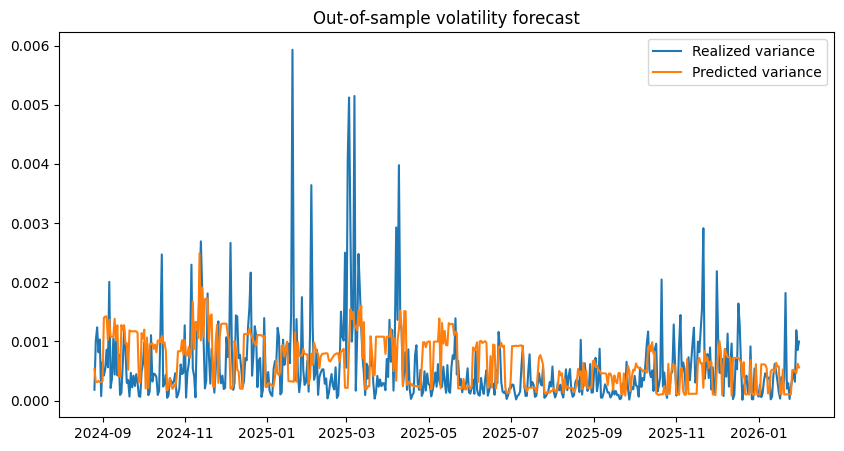

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(test_stage2["date"], test_stage2["actual_var"], label="Realized variance")
plt.plot(test_stage2["date"], test_stage2["var_soft"], label="Predicted variance")
plt.legend()
plt.title("Out-of-sample volatility forecast")
plt.show()

In [23]:
# predicted regime vs actual regime confusion matrix
from sklearn.metrics import confusion_matrix, classification_report
cm = confusion_matrix(test_stage2["true_regime"], test_stage2["pred_regime"])
print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(test_stage2["true_regime"], test_stage2["pred_regime"]))


Confusion Matrix:
[[109 131]
 [ 91 193]]

Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.45      0.50       240
           1       0.60      0.68      0.63       284

    accuracy                           0.58       524
   macro avg       0.57      0.57      0.57       524
weighted avg       0.57      0.58      0.57       524



In [27]:
# predicted regime probabilities for test set
test_results.head(10)

,date,actual_var,true_regime,pred_prob_0,pred_prob_1,var_low,var_high,var_soft,pred_regime
0,2024-08-26,0.000184,0,9.999895e-01,1.054464e-05,0.000540,0.000887,0.000540,0
1,2024-08-27,0.001012,1,9.999977e-01,2.215769e-06,0.000314,0.000887,0.000314,0
2,2024-08-28,0.001237,1,9.998366e-01,1.633597e-04,0.000314,0.001178,0.000314,0
3,2024-08-29,0.000816,1,9.856547e-01,1.434536e-02,0.000314,0.001573,0.000332,0
4,2024-08-30,0.001032,1,9.999996e-01,3.206164e-07,0.000314,0.001091,0.000314,0
5,2024-08-31,0.000076,0,9.999999e-01,1.197405e-07,0.000314,0.001433,0.000314,0
6,2024-09-01,0.000654,0,9.999826e-01,1.736735e-05,0.000329,0.001422,0.000329,0
7,2024-09-02,0.000422,0,2.152218e-02,9.784778e-01,0.000388,0.001422,0.001400,1
8,2024-09-03,0.000536,0,3.691978e-05,9.999630e-01,0.000583,0.001422,0.001422,1
9,2024-09-04,0.000861,1,1.629921e-10,1.000000e+00,0.000470,0.001422,0.001422,1
